In [80]:
import nltk
# nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
# nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Rajan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Rajan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Rajan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [81]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import re, contractions
# from nltk.tokenize import word_tokenize

In [82]:
df = pd.read_csv('data/imdb.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [83]:
df['sentiment'].unique()

<StringArray>
['positive', 'negative']
Length: 2, dtype: str

In [84]:
df["sentiment"] = df["sentiment"].map({
"positive": 1,
"negative": 0
})

In [85]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [86]:
#utils
def preprocess(text):
    text = text.lower()
    text = contractions.fix(text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

In [87]:
df["review"] = df["review"].apply(preprocess)

In [88]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production br br the filmin...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there is a family where a little boy...,0
4,petter matteis love in the time of money is a ...,1


In [89]:
X = df['review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [91]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [92]:
max_len = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [93]:
# model = Sequential([
#     Embedding(input_dim=10000, output_dim=128, input_length=max_len), #dim 5000
#     LSTM(64),
#     Dense(1, activation='sigmoid')
# ])

from tensorflow.keras.layers import Dropout

# model = Sequential([
#     Embedding(10000, 128, input_length=max_len),
#     LSTM(64, return_sequences=True),
#     Dropout(0.3),
#     LSTM(32),
#     Dropout(0.3),
#     Dense(1, activation='sigmoid')
# ])

model = Sequential([
    Embedding(10000, 128, input_length=max_len),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

D:\Rajan_Rajawat\OneDrive - werqlabs.com\Tasks\Working\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [94]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# model.fit(
#     X_train_pad,
#     y_train,
#     epochs=5,
#     batch_size=32,
#     validation_data=(X_test_pad, y_test)
# )

history = model.fit(
    X_train_pad,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop]
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 112s 86ms/step - accuracy: 0.6144 - loss: 0.6382 - val_accuracy: 0.7681 - val_loss: 0.5235
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 115s 92ms/step - accuracy: 0.8296 - loss: 0.4105 - val_accuracy: 0.8772 - val_loss: 0.3057
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 88ms/step - accuracy: 0.8906 - loss: 0.2735 - val_accuracy: 0.8912 - val_loss: 0.2669
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 88ms/step - accuracy: 0.8778 - loss: 0.3040 - val_accuracy: 0.8740 - val_loss: 0.3156
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 110s 88ms/step - accuracy: 0.9118 - loss: 0.2293 - val_accuracy: 0.8878 - val_loss: 0.2742


In [95]:
loss, accuracy = model.evaluate(X_test_pad, y_test)
print("Loss:", loss)
print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.8912 - loss: 0.2669
Loss: 0.26689979434013367
Accuracy: 0.8912000060081482


In [96]:
# y_pred = model.predict(X_test_pad)

In [97]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      4961
           1       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

[[4312  649]
 [ 439 4600]]


In [98]:
train_loss, train_acc = model.evaluate(X_train_pad, y_train)
print("Train Accuracy:", train_acc)
test_loss, test_acc = model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", test_acc)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.9222 - loss: 0.2130
Train Accuracy: 0.9221749901771545
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8912 - loss: 0.2669
Test Accuracy: 0.8912000060081482


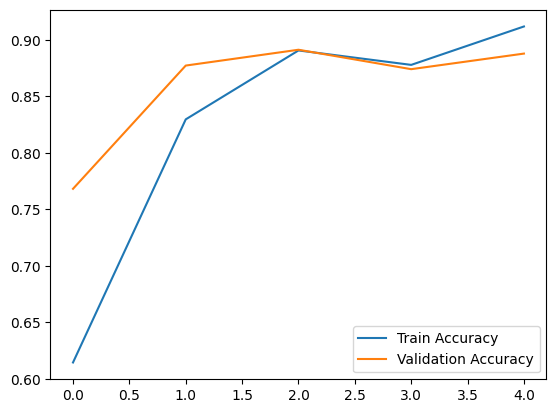

In [99]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.legend()
plt.show()

In [100]:
def predict_sentiment(text):
    text = preprocess(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=100)
    
    pred = model.predict(pad)[0][0]
    
    print("Raw prediction:", pred)
    
    return "positive" if pred > 0.5 else "negative"

In [106]:
while True:
    user_input = input("\nEnter a review ('e' to quit): ")
    if user_input.lower() == 'e':
        break
    print(f"Predicted Sentiment: {predict_sentiment(user_input)}")


Enter a review (or 'exit' to quit):  i hate this product


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw prediction: 0.46220738
Predicted Sentiment: negative



Enter a review (or 'exit' to quit):  this movie is shit


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Raw prediction: 0.4969536
Predicted Sentiment: negative



Enter a review (or 'exit' to quit):  i love this


...


Enter a review (or 'exit' to quit):  this is very bad 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Raw prediction: 0.21667396
Predicted Sentiment: negative



Enter a review (or 'exit' to quit):  amazing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Raw prediction: 0.6656463
Predicted Sentiment: positive



Enter a review (or 'exit' to quit):  exit


In [102]:
print(df['sentiment'].value_counts())

sentiment
1    25000
0    25000
Name: count, dtype: int64


In [103]:
print(tokenizer.word_index.get("not"))

13


In [104]:
print(tokenizer.texts_to_sequences(["i hate this product"]))

[[10, 715, 11, 2096]]


In [105]:
print(preprocess("I don't like this"))

i do not like this
